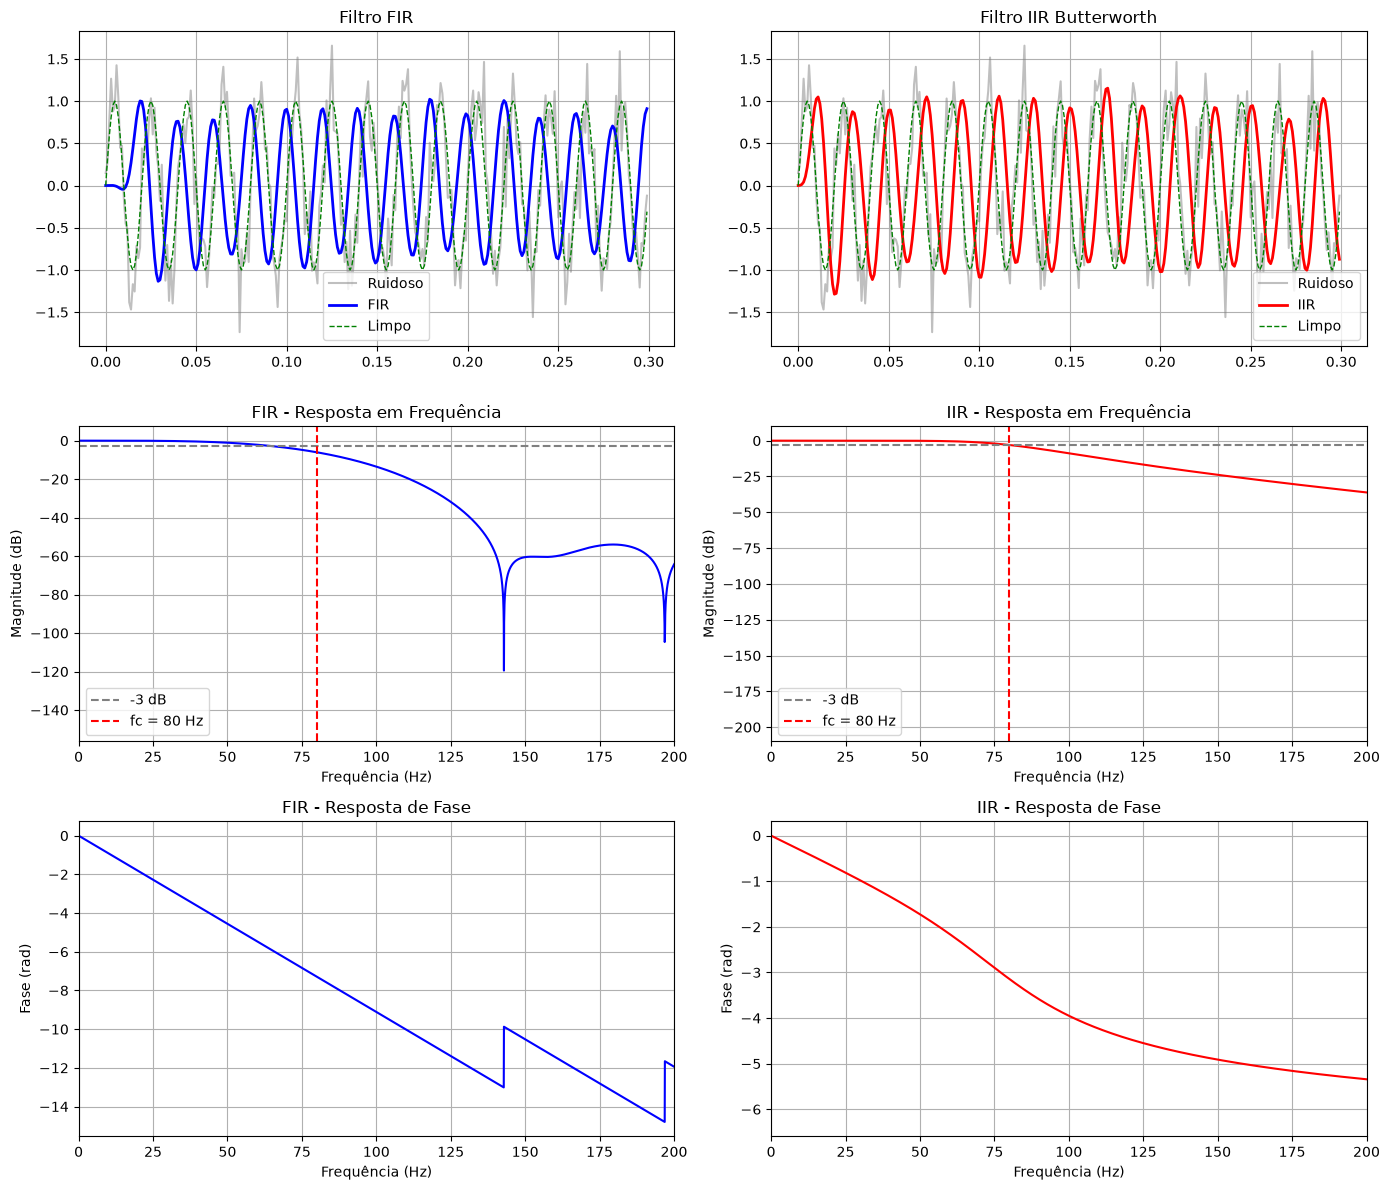

SNR - FIR: -3.17 dB
SNR - IIR: -3.54 dB
Diferença de desempenho: -0.37 dB
Ordem FIR: 30
Ordem IIR: 4


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Parâmetros
fs = 1000
t = np.arange(0, 2, 1/fs)
f_sinal = 50
sinal_limpo = np.sin(2*np.pi*f_sinal*t)
np.random.seed(42)
ruido = 0.3 * np.random.randn(len(t))
sinal_ruidoso = sinal_limpo + ruido

# Projeto dos filtros
fc = 80  # Frequência de corte (Hz)

# FIR
ordem_fir = 30
b_fir = signal.firwin(ordem_fir, fc, fs=fs, window='hamming')

# IIR Butterworth
ordem_iir = 4  # Ordem baixa para demonstrar a eficiência
b_iir, a_iir = signal.butter(ordem_iir, fc, fs=fs, btype='low')

# Aplicação dos filtros
sinal_fir = signal.lfilter(b_fir, [1.0], sinal_ruidoso)
sinal_iir = signal.lfilter(b_iir, a_iir, sinal_ruidoso)

# Respostas em frequência
w_fir, h_fir = signal.freqz(b_fir, [1.0], worN=8000, fs=fs)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=8000, fs=fs)

# Cálculo de SNR
def calcular_snr_efetivo(original, processado, limpo):
    ruido_original = original - limpo
    ruido_processado = processado - limpo
    return 10 * np.log10(np.var(limpo) / np.var(ruido_processado))

snr_fir = calcular_snr_efetivo(sinal_ruidoso, sinal_fir, sinal_limpo)
snr_iir = calcular_snr_efetivo(sinal_ruidoso, sinal_iir, sinal_limpo)

# Gráficos
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Sinal no tempo
axes[0, 0].plot(t[:300], sinal_ruidoso[:300], 'gray', alpha=0.5, label='Ruidoso')
axes[0, 0].plot(t[:300], sinal_fir[:300], 'b', label='FIR', linewidth=2)
axes[0, 0].plot(t[:300], sinal_limpo[:300], 'g--', label='Limpo', linewidth=1)
axes[0, 0].set_title('Filtro FIR')
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(t[:300], sinal_ruidoso[:300], 'gray', alpha=0.5, label='Ruidoso')
axes[0, 1].plot(t[:300], sinal_iir[:300], 'r', label='IIR', linewidth=2)
axes[0, 1].plot(t[:300], sinal_limpo[:300], 'g--', label='Limpo', linewidth=1)
axes[0, 1].set_title('Filtro IIR Butterworth')
axes[0, 1].legend()
axes[0, 1].grid()

# Resposta em frequência - Magnitude
axes[1, 0].plot(w_fir, 20*np.log10(np.abs(h_fir) + 1e-10), 'b')
axes[1, 0].axhline(-3, color='gray', linestyle='--', label='-3 dB')
axes[1, 0].axvline(fc, color='r', linestyle='--', label=f'fc = {fc} Hz')
axes[1, 0].set_xlabel('Frequência (Hz)')
axes[1, 0].set_ylabel('Magnitude (dB)')
axes[1, 0].set_title('FIR - Resposta em Frequência')
axes[1, 0].set_xlim(0, 200)
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].plot(w_iir, 20*np.log10(np.abs(h_iir) + 1e-10), 'r')
axes[1, 1].axhline(-3, color='gray', linestyle='--', label='-3 dB')
axes[1, 1].axvline(fc, color='r', linestyle='--', label=f'fc = {fc} Hz')
axes[1, 1].set_xlabel('Frequência (Hz)')
axes[1, 1].set_ylabel('Magnitude (dB)')
axes[1, 1].set_title('IIR - Resposta em Frequência')
axes[1, 1].set_xlim(0, 200)
axes[1, 1].legend()
axes[1, 1].grid()

# Resposta em fase
axes[2, 0].plot(w_fir, np.unwrap(np.angle(h_fir)), 'b')
axes[2, 0].set_xlabel('Frequência (Hz)')
axes[2, 0].set_ylabel('Fase (rad)')
axes[2, 0].set_title('FIR - Resposta de Fase')
axes[2, 0].set_xlim(0, 200)
axes[2, 0].grid()

axes[2, 1].plot(w_iir, np.unwrap(np.angle(h_iir)), 'r')
axes[2, 1].set_xlabel('Frequência (Hz)')
axes[2, 1].set_ylabel('Fase (rad)')
axes[2, 1].set_title('IIR - Resposta de Fase')
axes[2, 1].set_xlim(0, 200)
axes[2, 1].grid()

plt.tight_layout()
plt.show()

print(f"SNR - FIR: {snr_fir:.2f} dB")
print(f"SNR - IIR: {snr_iir:.2f} dB")
print(f"Diferença de desempenho: {snr_iir - snr_fir:.2f} dB")
print(f"Ordem FIR: {ordem_fir}")
print(f"Ordem IIR: {ordem_iir}")

# Discussão dos Resultados
O filtro IIR Butterworth de ordem 4 apresenta desempenho de atenuação de ruído comparável ao filtro FIR de ordem 30, demonstrando a eficiência computacional dos filtros IIR. A resposta em fase do FIR é linear, preservando a forma do sinal, enquanto a do IIR é não linear, introduzindo distorção de fase. Para esta aplicação específica, o IIR oferece melhor relação custo-benefício em termos de ordem e processamento.